First 5 Rows of Dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wor

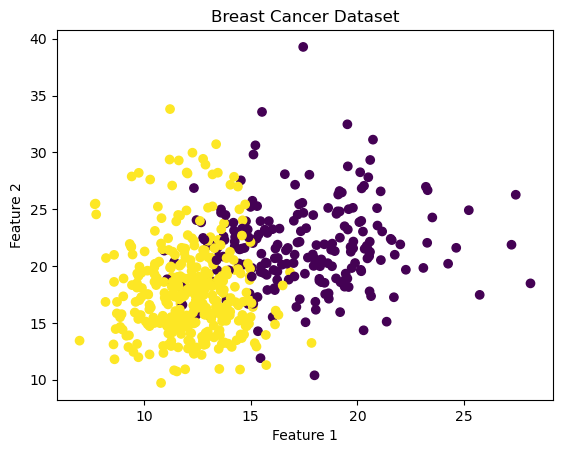


Confusion Matrix:
[[39  4]
 [ 1 70]]

Accuracy: 0.956140350877193
Precision: 0.9459459459459459
Recall: 0.9859154929577465
AUC Score: 0.9977071732721913


In [4]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score
)

# Load dataset
data = load_breast_cancer()

# Convert dataset into DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df["target"] = data.target

# Show first 5 rows
print("First 5 Rows of Dataset:")
print(df.head())

# Features and labels
X = data.data
y = data.target

# Visualize dataset (first two features)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Breast Cancer Dataset")
plt.show()

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LogisticRegression(max_iter=5000)

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Probability prediction for AUC
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation metrics
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Print results
print("\nConfusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("AUC Score:", auc)